## 1. Importar Librerías y Cargar Sistema

In [1]:
# Importar librerías necesarias
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías importadas exitosamente")

✅ Librerías importadas exitosamente


In [2]:
# Importar el sistema de recomendación
from coach_recommender import SmartCoachRecommender

print("✅ Sistema de recomendación importado")

✅ Sistema de recomendación importado


### ⚠️ Verificación de Prerequisitos

Antes de continuar, asegúrate de:
1. ✅ Haber ejecutado el notebook `01_Smart_Coach_Analysis.ipynb` para generar los modelos
2. ✅ Tener instalado **Ollama** (https://ollama.ai/)
3. ✅ Haber descargado un modelo LLM: `ollama pull llama2`

Si no tienes Ollama, el sistema fallará al intentar generar rutinas con el LLM.

In [3]:
# Verificar que existen los archivos necesarios
import os

archivos_necesarios = [
    'kmeans_model.pkl',
    'scaler.pkl',
    'label_encoders.pkl',
    'usuarios_con_clusters.csv'
]

print("🔍 Verificando archivos necesarios...\n")

todos_existen = True
for archivo in archivos_necesarios:
    existe = os.path.exists(archivo)
    simbolo = "✅" if existe else "❌"
    print(f"{simbolo} {archivo}")
    if not existe:
        todos_existen = False

if todos_existen:
    print("\n✅ Todos los archivos necesarios están disponibles")
else:
    print("\n❌ Faltan archivos. Por favor ejecuta primero el notebook de análisis.")

🔍 Verificando archivos necesarios...

✅ kmeans_model.pkl
✅ scaler.pkl
✅ label_encoders.pkl
✅ usuarios_con_clusters.csv

✅ Todos los archivos necesarios están disponibles


In [4]:
# Inicializar el sistema de recomendación
print("🚀 Inicializando Smart Coach AI...\n")

coach = SmartCoachRecommender(
    modelo_path='kmeans_model.pkl',
    scaler_path='scaler.pkl',
    encoders_path='label_encoders.pkl',
    dataset_path='usuarios_con_clusters.csv',
    llm_model='llama3'  # Puedes cambiar a 'mistral', 'codellama', etc.
)

print("\n✅ Sistema inicializado correctamente")

🚀 Inicializando Smart Coach AI...

✅ Smart Coach Recommender inicializado
   • Modelo: llama3
   • Clusters disponibles: 4
   • Usuarios en dataset: 1000

✅ Sistema inicializado correctamente
✅ Smart Coach Recommender inicializado
   • Modelo: llama3
   • Clusters disponibles: 4
   • Usuarios en dataset: 1000

✅ Sistema inicializado correctamente


c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\01_Smart_Coach_IA\coach_recommender.py:50: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  self.llm = Ollama(model=llm_model, temperature=0.7)


## 2. Explorar Clusters Disponibles

Primero, veamos qué tipos de perfiles existen en el sistema.

In [5]:
# Ver resumen de todos los clusters
print("📊 CLUSTERS DISPONIBLES EN EL SISTEMA")
print("=" * 100)

clusters_df = coach.listar_clusters()
display(clusters_df)

print("\n💡 Cada cluster representa un grupo de usuarios con características similares.")

📊 CLUSTERS DISPONIBLES EN EL SISTEMA


,Cluster,N° Usuarios,Experiencia,Objetivo,Equipo,Tiempo Prom.,Frecuencia,Edad Prom.
0,0,197,Avanzado,Resistencia,Solo peso corporal,67 min,4.4 días,40 años
1,1,256,Intermedio,Salud general,Casa con equipo,72 min,5.9 días,41 años
2,2,259,Intermedio,Ganar músculo,Casa con equipo,65 min,5.4 días,47 años
3,3,288,Principiante,Pérdida de peso,Solo peso corporal,67 min,2.8 días,37 años



💡 Cada cluster representa un grupo de usuarios con características similares.


In [6]:
# Visualizar distribución de usuarios por cluster
fig = go.Figure(data=[
    go.Bar(
        x=[f"Cluster {i}" for i in range(len(clusters_df))],
        y=clusters_df['N° Usuarios'],
        text=clusters_df['N° Usuarios'],
        textposition='auto',
        marker_color=['#1E88E5', '#43A047', '#FB8C00', '#E53935']
    )
])

fig.update_layout(
    title='Distribución de Usuarios por Cluster',
    xaxis_title='Cluster',
    yaxis_title='Número de Usuarios',
    height=500,
    template='plotly_white'
)

fig.show()

## 3. Casos de Uso - Diferentes Perfiles de Usuario

Vamos a probar el sistema con 4 perfiles diferentes que representan usuarios típicos.

### 👤 Usuario 1: María - Principiante que quiere perder peso

In [ ]:
# Perfil de María
usuario_maria = {
    'experiencia': 'Principiante',
    'objetivo': 'Pérdida de peso',
    'equipo': 'Solo peso corporal',
    'tiempo_disponible': 30,
    'frecuencia_semanal': 3,
    'edad': 32,
    'restricciones': 'Rodilla'
}

print("👤 PERFIL: MARÍA")
print("=" * 80)
for key, value in usuario_maria.items():
    print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n🔄 Generando recomendación personalizada...")

👤 PERFIL: MARÍA
  • Experiencia: Principiante
  • Objetivo: Pérdida de peso
  • Equipo: Solo peso corporal
  • Tiempo Disponible: 30
  • Frecuencia Semanal: 3
  • Edad: 32
  • Restricciones: Rodilla

🔄 Generando recomendación personalizada...
⏳ Esto puede tomar 30-60 segundos mientras el LLM genera la rutina...



In [ ]:
# Generar recomendación para María
resultado_maria = coach.recomendar(usuario_maria)

if resultado_maria['error']:
    print(f"❌ Error: {resultado_maria['mensaje']}")
    for error in resultado_maria['errores']:
        print(f"   • {error}")
else:
    print("✅ ¡Recomendación generada exitosamente!\n")
    print(f"📊 Cluster asignado: {resultado_maria['cluster_id']}")
    print(f"👥 Usuarios similares: {resultado_maria['cluster_profile']['n_usuarios']}")
    print(f"\n" + "=" * 80)

🤖 Generando rutina con LLM para Cluster 3...


c:\Users\c0d06h6\OneDrive - Walmart Inc\Cesar Delgado\--PERSONAL\Proyectos_Personales\01_Smart_Coach_IA\coach_recommender.py:101: LangChainDeprecationWarning:

The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.



✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 3
👥 Usuarios similares: 288



In [9]:
# Mostrar rutina de María
from IPython.display import Markdown, display

print("\n📝 RUTINA PERSONALIZADA PARA MARÍA")
print("=" * 80)
display(Markdown(resultado_maria['rutina']))


📝 RUTINA PERSONALIZADA PARA MARÍA


# 🏋️ Tu Rutina Personalizada

**RUTINA DE ENTRENAMIENTO PERSONALIZADA**

**DÍA LUNES - Pérdida de peso y fortaleza**

🔥 Calentamiento (5 minutos):
- Marcha en lugar sin apoyo (30 segundos)
- Flexiones de hombros (20 segundos)

💪 Entrenamiento Principal:
1. Sentadillas con piernas rectas: 3 sets × 12 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su parte inferior del cuerpo, lo que ayudará a mejorar la postura y reducir la grasa en las piernas.
2. Peso corporal: 3 sets × 10 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su musculatura general, lo que ayudará a mejorar la metabolismo y la pérdida de peso.

❄️ Enfriamiento (5 minutos):
- Estiramientos para piernas: 30 segundos por músculo

📝 NOTAS IMPORTANTES:
* Recuerda mantener una postura recta durante los ejercicios y no sobrepasar tus límites físicos.
* Asegúrate de beber suficiente agua antes, durante y después del entrenamiento.

**DÍA MIÉRCOLES - Fortaleza y equilibrio**

🔥 Calentamiento (5 minutos):
- Marcha en lugar sin apoyo (30 segundos)
- Estiramientos para hombros (20 segundos)

💪 Entrenamiento Principal:
1. Peso corporal: 3 sets × 10 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su musculatura general, lo que ayudará a mejorar la metabolismo y la pérdida de peso.
2. Sentadillas con piernas flexionadas: 3 sets × 12 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su parte inferior del cuerpo, lo que ayudará a mejorar la postura y reducir la grasa en las piernas.

❄️ Enfriamiento (5 minutos):
- Estiramientos para piernas: 30 segundos por músculo

📝 NOTAS IMPORTANTES:
* Recuerda mantener una postura recta durante los ejercicios y no sobrepasar tus límites físicos.
* Asegúrate de beber suficiente agua antes, durante y después del entrenamiento.

**DÍA VIERNES - Pérdida de peso y fortaleza**

🔥 Calentamiento (5 minutos):
- Marcha en lugar sin apoyo (30 segundos)
- Flexiones de hombros (20 segundos)

💪 Entrenamiento Principal:
1. Peso corporal: 3 sets × 10 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su musculatura general, lo que ayudará a mejorar la metabolismo y la pérdida de peso.
2. Sentadillas con piernas rectas: 3 sets × 12 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado porque el usuario puede hacerlo sin necesidad de equipo adicional y fortalecerá su parte inferior del cuerpo, lo que ayudará a mejorar la postura y reducir la grasa en las piernas.

❄️ Enfriamiento (5 minutos):
- Estiramientos para piernas: 30 segundos por músculo

🎯 PROGRESIÓN:
* Aumenta el número de sets o reps cada 2 semanas.
* Incorpora ejercicios que trabajen los músculos laterales y abdominales, como pliés y crunches, a medida que te sientas más cómodo con la rutina actual.

Espero que esta rutina personalizada sea útil para el usuario. Recuerda que es importante escuchar a tu cuerpo y ajustar la intensidad y duración de acuerdo a tus necesidades individuales.

In [10]:
# Mostrar recomendaciones adicionales
print("\n💡 RECOMENDACIONES ADICIONALES")
print("=" * 80)
for rec in resultado_maria['recomendaciones_adicionales']:
    print(f"  {rec}")


💡 RECOMENDACIONES ADICIONALES
  🔰 Como principiante, enfócate en la técnica correcta antes que en el peso
  📱 Considera usar videos de referencia para aprender los ejercicios
  🥗 La nutrición es crucial: mantén un déficit calórico moderado
  🚶 Considera agregar caminatas diarias de 20-30 minutos
  ⚠️ Ten especial cuidado con ejercicios que involucren rodilla
  🏥 Consulta con un fisioterapeuta si el dolor persiste o empeora


---
### 👤 Usuario 2: Carlos - Intermedio que quiere ganar músculo

In [11]:
# Perfil de Carlos
usuario_carlos = {
    'experiencia': 'Intermedio',
    'objetivo': 'Ganar músculo',
    'equipo': 'Gimnasio completo',
    'tiempo_disponible': 75,
    'frecuencia_semanal': 5,
    'edad': 28,
    'restricciones': 'Ninguna'
}

print("👤 PERFIL: CARLOS")
print("=" * 80)
for key, value in usuario_carlos.items():
    print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n🔄 Generando recomendación personalizada...\n")

👤 PERFIL: CARLOS
  • Experiencia: Intermedio
  • Objetivo: Ganar músculo
  • Equipo: Gimnasio completo
  • Tiempo Disponible: 75
  • Frecuencia Semanal: 5
  • Edad: 28
  • Restricciones: Ninguna

🔄 Generando recomendación personalizada...



In [12]:
# Generar recomendación para Carlos
resultado_carlos = coach.recomendar(usuario_carlos)

if resultado_carlos['error']:
    print(f"❌ Error: {resultado_carlos['mensaje']}")
else:
    print("✅ ¡Recomendación generada exitosamente!\n")
    print(f"📊 Cluster asignado: {resultado_carlos['cluster_id']}")
    print(f"👥 Usuarios similares: {resultado_carlos['cluster_profile']['n_usuarios']}")
    print("\n" + "=" * 80)
    print("\n📝 RUTINA PERSONALIZADA PARA CARLOS")
    print("=" * 80)
    display(Markdown(resultado_carlos['rutina']))
    
    print("\n💡 RECOMENDACIONES ADICIONALES")
    print("=" * 80)
    for rec in resultado_carlos['recomendaciones_adicionales']:
        print(f"  {rec}")

🤖 Generando rutina con LLM para Cluster 2...
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 2
👥 Usuarios similares: 259


📝 RUTINA PERSONALIZADA PARA CARLOS
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 2
👥 Usuarios similares: 259


📝 RUTINA PERSONALIZADA PARA CARLOS


# 🏋️ Tu Rutina Personalizada

**Rutina Personalizada para Ganar Músculo**

**DÍA Lunes - Entrenamiento de Peso Corporal y Ejercicios de Fuerza**

🔥 Calentamiento (10 minutos):
- Marcha en el treadmill a una intensidad moderada
- Flexiones de hombros con pesas livianas

💪 Entrenamiento Principal:
1. Squats con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ Este ejercicio es adecuado para este usuario porque ayuda a ganar músculo en las piernas y glúteos, lo que es importante para un objetivo principal de ganar músculo. El peso corporal es una excelente forma de entrenamiento para fortalecer los músculos.
2. Deadlifts con pesas: 3 sets × 6 reps (descanso: 75 seg)
	→ Los deadlifts son un ejercicio fundamental para fortalecer los músculos del tronco, piernas y hombros. Ayuda a desarrollar la fuerza y el poder en todo el cuerpo.

❄️ Enfriamiento (5 minutos):
- Estiramientos de piernas y glúteos

**DÍA Martes - Entrenamiento de Hombros y Espalda**

🔥 Calentamiento (10 minutos):
- Ciclismo estático en el bike
- Elevaciones laterales con pesas livianas

💪 Entrenamiento Principal:
1. Shoulder Press con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ El entrenamiento de hombros es importante para un objetivo principal de ganar músculo, ya que ayuda a desarrollar la fuerza y el poder en los músculos del tronco y piernas. El shoulder press es un ejercicio efectivo para fortalecer los músculos de los hombros.
2. Bent-Over Rows con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ Los rows ayudan a desarrollar la fuerza y el poder en los músculos de la espalda, que es importante para un objetivo principal de ganar músculo.

❄️ Enfriamiento (5 minutos):
- Estiramientos de hombros y espalda

**DÍA Miércoles - Entrenamiento de Piernas**

🔥 Calentamiento (10 minutos):
- Marcha en el treadmill a una intensidad moderada
- Flexiones de piernas con pesas livianas

💪 Entrenamiento Principal:
1. Leg Press con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ El entrenamiento de piernas es importante para un objetivo principal de ganar músculo, ya que ayuda a desarrollar la fuerza y el poder en los músculos de las piernas. La leg press es un ejercicio efectivo para fortalecer los músculos de las piernas.
2. Leg Extensions con pesas: 3 sets × 12 reps (descanso: 45 seg)
	→ Las extensions de piernas son un ejercicio fundamental para fortalecer los músculos de las piernas.

❄️ Enfriamiento (5 minutos):
- Estiramientos de piernas y glúteos

**DÍA Jueves - Entrenamiento de Tronco**

🔥 Calentamiento (10 minutos):
- Ciclismo estático en el bike
- Elevaciones laterales con pesas livianas

💪 Entrenamiento Principal:
1. Bench Press con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ El entrenamiento de tronco es importante para un objetivo principal de ganar músculo, ya que ayuda a desarrollar la fuerza y el poder en los músculos del tronco. La bench press es un ejercicio efectivo para fortalecer los músculos del pecho.
2. Pull-Ups con pesas: 3 sets × 8 reps (descanso: 60 seg)
	→ Los pull-ups son un ejercicio fundamental para fortalecer los músculos de la espalda y los brazos.

❄️ Enfriamiento (5 minutos):
- Estiramientos de tronco y brazos

**DÍA Viernes - Entrenamiento de Brazos**

🔥 Calentamiento (10 minutos):
- Ciclismo estático en el bike
- Elevaciones laterales con pesas livianas

💪 Entrenamiento Principal:
1. Bicep Curls con pesas: 3 sets × 12 reps (descanso: 45 seg)
	→ El entrenamiento de brazos es importante para un objetivo principal de ganar músculo, ya que ayuda a desarrollar la fuerza y el poder en los músculos de los brazos. Las curls son un ejercicio efectivo para fortalecer los músculos de los brazos.
2. Tricep Extensions con pesas: 3 sets × 12 reps (descanso: 45 seg)
	→ Las extensions de tríceps son un ejercicio fundamental para fortalecer los músculos de los brazos.

❄️ Enfriamiento (5 minutos):
- Estiramientos de brazos y piernas

**NOTAS IMPORTANTES**

* Asegúrate de calentarte adecuadamente antes de cada sesión.
* Utiliza pesas que te permitan completar las repeticiones con buena forma, pero no tan livianas que no desafien tu cuerpo.
* Ajusta el peso y la intensidad según sea necesario para evitar lesiones.
* No olvides estiramientos después de cada sesión para prevenir lesiones y mejorar la flexibilidad.

**PROGRESIÓN**

* En 2 semanas, aumenta el peso o la resistencia en cada ejercicio por 5-10%.
* En 4 semanas, cambia los ejercicios principales por otros que targetizen diferentes músculos.
* Asegúrate de escuchar a tu cuerpo y no descuides tus sesiones. ¡Buena suerte!


💡 RECOMENDACIONES ADICIONALES
  💪 Asegura consumir suficiente proteína: 1.6-2.2g por kg de peso corporal
  😴 El descanso es crucial para el crecimiento muscular
  🔄 Con alta frecuencia, alterna entre grupos musculares para evitar sobreentrenamiento


---
### 👤 Usuario 3: Ana - Avanzada enfocada en resistencia

In [13]:
# Perfil de Ana
usuario_ana = {
    'experiencia': 'Avanzado',
    'objetivo': 'Resistencia',
    'equipo': 'Casa con equipo',
    'tiempo_disponible': 60,
    'frecuencia_semanal': 6,
    'edad': 35,
    'restricciones': 'Ninguna'
}

print("👤 PERFIL: ANA")
print("=" * 80)
for key, value in usuario_ana.items():
    print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n🔄 Generando recomendación personalizada...\n")

👤 PERFIL: ANA
  • Experiencia: Avanzado
  • Objetivo: Resistencia
  • Equipo: Casa con equipo
  • Tiempo Disponible: 60
  • Frecuencia Semanal: 6
  • Edad: 35
  • Restricciones: Ninguna

🔄 Generando recomendación personalizada...



In [14]:
# Generar recomendación para Ana
resultado_ana = coach.recomendar(usuario_ana)

if resultado_ana['error']:
    print(f"❌ Error: {resultado_ana['mensaje']}")
else:
    print("✅ ¡Recomendación generada exitosamente!\n")
    print(f"📊 Cluster asignado: {resultado_ana['cluster_id']}")
    print(f"👥 Usuarios similares: {resultado_ana['cluster_profile']['n_usuarios']}")
    print("\n" + "=" * 80)
    print("\n📝 RUTINA PERSONALIZADA PARA ANA")
    print("=" * 80)
    display(Markdown(resultado_ana['rutina']))
    
    print("\n💡 RECOMENDACIONES ADICIONALES")
    print("=" * 80)
    for rec in resultado_ana['recomendaciones_adicionales']:
        print(f"  {rec}")

🤖 Generando rutina con LLM para Cluster 0...
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 0
👥 Usuarios similares: 197


📝 RUTINA PERSONALIZADA PARA ANA
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 0
👥 Usuarios similares: 197


📝 RUTINA PERSONALIZADA PARA ANA


# 🏋️ Tu Rutina Personalizada

**Rutina Personalizada para el Usuario**

**DÍA 1 - Día de Resistencia General**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Sentadillas con pesas: 3 sets × 10 reps (descanso: 60 segundos)
	→ Esta ejercicio es adecuada para el usuario avanzado que busca resistencia, ya que trabaja músculos como los glúteos y cuádriceps.
2. Prensa con barra de pesas: 3 sets × 8 reps (descanso: 60 segundos)
	→ La prensa es un ejercicio efectivo para trabajar el pecho y los hombros, lo que es importante para la resistencia general.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una buena postura durante las sentadillas.
- Puede aumentar el peso utilizado en las prensas a medida que mejore la resistencia.

**DÍA 2 - Día de Fuerza en los Hombros**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Elevaciones laterales con pesas: 3 sets × 12 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos deltoides, lo que es importante para la resistencia en general.
2. Peso muerto con barra de pesas: 3 sets × 8 reps (descanso: 60 segundos)
	→ El peso muerto es un ejercicio efectivo para trabajar el hombro y los músculos del brazo.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una postura recta durante las elevaciones laterales.
- Puede aumentar el peso utilizado en los pesos muertos a medida que mejore la resistencia.

**DÍA 3 - Día de Fuerza en los Pies y Caderas**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Sentadillas con pesas: 3 sets × 10 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos glúteos y cuádriceps, lo que es importante para la resistencia general.
2. Extensiones de piernas con pesas: 3 sets × 12 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos isquiotibiales y semitendinosos, lo que es importante para la resistencia general.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una buena postura durante las sentadillas.
- Puede aumentar el peso utilizado en las extensiones de piernas a medida que mejore la resistencia.

**DÍA 4 - Día de Resistencia General**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Prensa con barra de pesas: 3 sets × 8 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente el pecho y los hombros, lo que es importante para la resistencia general.
2. Sentadillas con pesas: 3 sets × 10 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos glúteos y cuádriceps, lo que es importante para la resistencia general.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una buena postura durante las sentadillas.
- Puede aumentar el peso utilizado en las prensas a medida que mejore la resistencia.

**DÍA 5 - Día de Fuerza en los Brazos y Escapularios**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Elevaciones frontales con pesas: 3 sets × 12 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos deltoides y trapezios, lo que es importante para la resistencia general.
2. Peso muerto con barra de pesas: 3 sets × 8 reps (descanso: 60 segundos)
	→ El peso muerto es un ejercicio efectivo para trabajar el hombro y los músculos del brazo.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una postura recta durante las elevaciones frontales.
- Puede aumentar el peso utilizado en los pesos muertos a medida que mejore la resistencia.

**DÍA 6 - Día de Resistencia General**

🔥 Calentamiento (5 minutos):
- Marcha en place (30 segundos)
- Stretching del cuello y hombros (20 segundos)

💪 Entrenamiento Principal:
1. Sentadillas con pesas: 3 sets × 10 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente los músculos glúteos y cuádriceps, lo que es importante para la resistencia general.
2. Prensa con barra de pesas: 3 sets × 8 reps (descanso: 60 segundos)
	→ Estos ejercicios trabajan específicamente el pecho y los hombros, lo que es importante para la resistencia general.

❄️ Enfriamiento (5 minutos):
- Estiramientos del cuello y hombros

📝 NOTAS IMPORTANTES:
- Asegúrese de mantener una buena postura durante las sentadillas.
- Puede aumentar el peso utilizado en las prensas a medida que mejore la resistencia.

**PROGRESIÓN**

Para progresar en 2-4 semanas, el usuario puede:

* Aumentar el peso utilizado en los ejercicios
* Reducir el tiempo de descanso entre series y sets
* Agregar nuevos ejercicios que trabajen diferentes grupos musculares

Es importante recordar que la progresión debe ser gradual y segura para evitar lesiones. Es fundamental escuchar al cuerpo y no forzar los músculos.


💡 RECOMENDACIONES ADICIONALES
  🔄 Con alta frecuencia, alterna entre grupos musculares para evitar sobreentrenamiento


---
### 👤 Usuario 4: Roberto - Intermedio enfocado en salud general

In [15]:
# Perfil de Roberto
usuario_roberto = {
    'experiencia': 'Intermedio',
    'objetivo': 'Salud general',
    'equipo': 'Casa con equipo',
    'tiempo_disponible': 45,
    'frecuencia_semanal': 4,
    'edad': 52,
    'restricciones': 'Espalda'
}

print("👤 PERFIL: ROBERTO")
print("=" * 80)
for key, value in usuario_roberto.items():
    print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n🔄 Generando recomendación personalizada...\n")

👤 PERFIL: ROBERTO
  • Experiencia: Intermedio
  • Objetivo: Salud general
  • Equipo: Casa con equipo
  • Tiempo Disponible: 45
  • Frecuencia Semanal: 4
  • Edad: 52
  • Restricciones: Espalda

🔄 Generando recomendación personalizada...



In [16]:
# Generar recomendación para Roberto
resultado_roberto = coach.recomendar(usuario_roberto)

if resultado_roberto['error']:
    print(f"❌ Error: {resultado_roberto['mensaje']}")
else:
    print("✅ ¡Recomendación generada exitosamente!\n")
    print(f"📊 Cluster asignado: {resultado_roberto['cluster_id']}")
    print(f"👥 Usuarios similares: {resultado_roberto['cluster_profile']['n_usuarios']}")
    print("\n" + "=" * 80)
    print("\n📝 RUTINA PERSONALIZADA PARA ROBERTO")
    print("=" * 80)
    display(Markdown(resultado_roberto['rutina']))
    
    print("\n💡 RECOMENDACIONES ADICIONALES")
    print("=" * 80)
    for rec in resultado_roberto['recomendaciones_adicionales']:
        print(f"  {rec}")

🤖 Generando rutina con LLM para Cluster 1...
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 1
👥 Usuarios similares: 256


📝 RUTINA PERSONALIZADA PARA ROBERTO
✅ ¡Recomendación generada exitosamente!

📊 Cluster asignado: 1
👥 Usuarios similares: 256


📝 RUTINA PERSONALIZADA PARA ROBERTO


# 🏋️ Tu Rutina Personalizada

**Rutina de Entrenamiento Personalizada**

**Día 1 - Cardio y Fuerza**

🔥 Calentamiento (5 minutos):
- Marcha en el lugar (3 minutos)
- Estiramientos del cuello y hombros (2 minutos)

💪 Entrenamiento Principal:
1. Treadmill o bicicleta estática: 20 minutos a un ritmo moderado
   → Cardio es fundamental para la salud general y ayuda a reducir el riesgo de enfermedades cardiovasculares.
2. Sentadillas con mancuernas (3 sets × 12 reps, descanso: 60 segundos)
   → Esta ejercicio fortalece los músculos del trasero y piernas, que son fundamentales para la estabilidad y movilidad.

❄️ Enfriamiento (5 minutos):
- Estiramientos de piernas y hombros

**Día 2 - Fuerza y Equilibrio**

🔥 Calentamiento (5 minutos):
- Marcha en el lugar (3 minutos)
- Estiramientos del cuello y hombros (2 minutos)

💪 Entrenamiento Principal:
1. Squats con pesas ligeras (3 sets × 12 reps, descanso: 60 segundos)
   → Esta ejercicio fortalece los músculos de las piernas y ayuda a mejorar la estabilidad.
2. Lunges (3 sets × 10 reps per side, descanso: 60 seconds)
   → Estos ejercicios ayudan a fortalecer los músculos de las piernas y mejorar el equilibrio.

❄️ Enfriamiento (5 minutos):
- Estiramientos de piernas y hombros

**Día 3 - Descanso**

📝 NOTAS IMPORTANTES:
- Asegúrese de beber suficiente agua antes, durante y después del entrenamiento.
- Evite realizar ejercicios que causen dolor en la espalda.

**Día 4 - Cardio y Fuerza**

🔥 Calentamiento (5 minutos):
- Marcha en el lugar (3 minutos)
- Estiramientos del cuello y hombros (2 minutos)

💪 Entrenamiento Principal:
1. Rowing machine o remo: 20 minutos a un ritmo moderado
   → Esto ayuda a fortalecer los músculos del pecho y mejorar la cardiovascular.
2. Shoulder press con pesas ligeras (3 sets × 12 reps, descanso: 60 segundos)
   → Esta ejercicio fortalece los músculos de los hombros y ayuda a mejorar el equilibrio.

❄️ Enfriamiento (5 minutos):
- Estiramientos de piernas y hombros

**Progresión**

* Semana 2-3: Añadir un set o una repetición a cada ejercicio.
* Semana 4-6: Cambiar los ejercicios para incluir nuevos desafíos, como sentadillas con pesas más pesadas o squats con pesas ligeras.

**Consejos personalizados**

* Asegúrese de escuchar su cuerpo y parar si siente dolor en la espalda.
* Incremente gradualmente el tiempo y la intensidad del entrenamiento a medida que se acostumbre.
* Beber suficiente agua y comer una dieta equilibrada para apoyar su entrenamiento.


💡 RECOMENDACIONES ADICIONALES
  ⚠️ Ten especial cuidado con ejercicios que involucren espalda
  🏥 Consulta con un fisioterapeuta si el dolor persiste o empeora


## 4. Análisis Comparativo de Usuarios

In [17]:
# Compilar resultados (solo si todos fueron exitosos)
usuarios_demo = [
    {'nombre': 'María', 'perfil': usuario_maria, 'resultado': resultado_maria},
    {'nombre': 'Carlos', 'perfil': usuario_carlos, 'resultado': resultado_carlos},
    {'nombre': 'Ana', 'perfil': usuario_ana, 'resultado': resultado_ana},
    {'nombre': 'Roberto', 'perfil': usuario_roberto, 'resultado': resultado_roberto}
]

# Crear DataFrame comparativo
comparacion_data = []
for usuario in usuarios_demo:
    if not usuario['resultado']['error']:
        comparacion_data.append({
            'Usuario': usuario['nombre'],
            'Experiencia': usuario['perfil']['experiencia'],
            'Objetivo': usuario['perfil']['objetivo'],
            'Tiempo (min)': usuario['perfil']['tiempo_disponible'],
            'Frecuencia': usuario['perfil']['frecuencia_semanal'],
            'Edad': usuario['perfil']['edad'],
            'Cluster': usuario['resultado']['cluster_id']
        })

df_comparacion = pd.DataFrame(comparacion_data)

print("📊 COMPARACIÓN DE USUARIOS Y CLUSTERS ASIGNADOS")
print("=" * 100)
display(df_comparacion)

📊 COMPARACIÓN DE USUARIOS Y CLUSTERS ASIGNADOS


,Usuario,Experiencia,Objetivo,Tiempo (min),Frecuencia,Edad,Cluster
0,María,Principiante,Pérdida de peso,30,3,32,3
1,Carlos,Intermedio,Ganar músculo,75,5,28,2
2,Ana,Avanzado,Resistencia,60,6,35,0
3,Roberto,Intermedio,Salud general,45,4,52,1


In [18]:
# Visualización: Características de los usuarios demo
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Tiempo Disponible', 'Frecuencia Semanal', 'Edad', 'Cluster Asignado'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# Tiempo disponible
fig.add_trace(
    go.Bar(x=df_comparacion['Usuario'], y=df_comparacion['Tiempo (min)'], 
           name='Tiempo', marker_color='#1E88E5'),
    row=1, col=1
)

# Frecuencia
fig.add_trace(
    go.Bar(x=df_comparacion['Usuario'], y=df_comparacion['Frecuencia'], 
           name='Frecuencia', marker_color='#43A047'),
    row=1, col=2
)

# Edad
fig.add_trace(
    go.Bar(x=df_comparacion['Usuario'], y=df_comparacion['Edad'], 
           name='Edad', marker_color='#FB8C00'),
    row=2, col=1
)

# Cluster
fig.add_trace(
    go.Bar(x=df_comparacion['Usuario'], y=df_comparacion['Cluster'], 
           name='Cluster', marker_color='#E53935'),
    row=2, col=2
)

fig.update_layout(
    height=700,
    showlegend=False,
    title_text="Características de los Usuarios Demo",
    template='plotly_white'
)

fig.show()

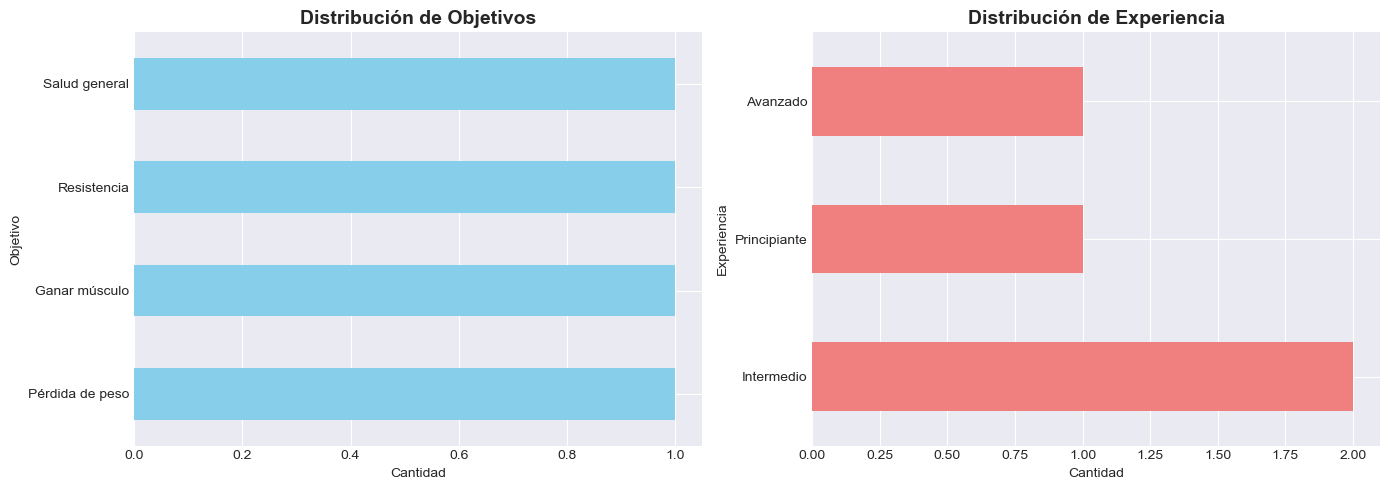

In [19]:
# Distribución de objetivos y experiencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Objetivos
df_comparacion['Objetivo'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Objetivos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('Objetivo')

# Experiencia
df_comparacion['Experiencia'].value_counts().plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Distribución de Experiencia', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Experiencia')

plt.tight_layout()
plt.show()

## 5. Prueba con Tu Propio Perfil

Ahora es tu turno. Define tu propio perfil y obtén una recomendación personalizada.

In [24]:
# Define tu perfil aquí
mi_perfil = {
    'experiencia': 'Intermedio',  # Opciones: 'Principiante', 'Intermedio', 'Avanzado'
    'objetivo': 'Ganar músculo',  # Opciones: 'Pérdida de peso', 'Ganar músculo', 'Resistencia', 'Salud general'
    'equipo': 'Gimnasio completo',  # Opciones: 'Gimnasio completo', 'Casa con equipo', 'Solo peso corporal'
    'tiempo_disponible': 75,  # Minutos: 15-120
    'frecuencia_semanal': 6,  # Días: 1-7
    'edad': 35,  # Años: 18-100
    'restricciones': 'Hombro'  # Opciones: 'Ninguna', 'Rodilla', 'Espalda', 'Hombro', 'Muñeca'
}

print("👤 TU PERFIL PERSONALIZADO")
print("=" * 80)
for key, value in mi_perfil.items():
    print(f"  • {key.replace('_', ' ').title()}: {value}")

print("\n🔄 Generando tu recomendación personalizada...\n")

👤 TU PERFIL PERSONALIZADO
  • Experiencia: Intermedio
  • Objetivo: Ganar músculo
  • Equipo: Gimnasio completo
  • Tiempo Disponible: 75
  • Frecuencia Semanal: 6
  • Edad: 35
  • Restricciones: Hombro

🔄 Generando tu recomendación personalizada...



In [25]:
# Generar recomendación para tu perfil
mi_resultado = coach.recomendar(mi_perfil)

if mi_resultado['error']:
    print(f"❌ Error: {mi_resultado['mensaje']}")
    for error in mi_resultado['errores']:
        print(f"   • {error}")
else:
    print("✅ ¡Tu recomendación ha sido generada exitosamente!\n")
    print(f"📊 Cluster asignado: {mi_resultado['cluster_id']}")
    print(f"👥 Usuarios similares a ti: {mi_resultado['cluster_profile']['n_usuarios']}")
    
    # Información del cluster
    cluster_profile = mi_resultado['cluster_profile']
    print(f"\n📋 Características de tu grupo:")
    print(f"   • Experiencia común: {cluster_profile['experiencia_comun']}")
    print(f"   • Objetivo común: {cluster_profile['objetivo_comun']}")
    print(f"   • Tiempo promedio: {cluster_profile['tiempo_promedio']:.0f} min")
    print(f"   • Frecuencia promedio: {cluster_profile['frecuencia_promedio']:.1f} días/semana")
    print(f"   • Edad promedio: {cluster_profile['edad_promedio']:.0f} años")
    
    print("\n" + "=" * 80)
    print("\n📝 TU RUTINA PERSONALIZADA")
    print("=" * 80)
    display(Markdown(mi_resultado['rutina']))
    
    print("\n💡 RECOMENDACIONES ADICIONALES PARA TI")
    print("=" * 80)
    for rec in mi_resultado['recomendaciones_adicionales']:
        print(f"  {rec}")

🤖 Generando rutina con LLM para Cluster 2...
✅ ¡Tu recomendación ha sido generada exitosamente!

📊 Cluster asignado: 2
👥 Usuarios similares a ti: 259

📋 Características de tu grupo:
   • Experiencia común: Intermedio
   • Objetivo común: Ganar músculo
   • Tiempo promedio: 65 min
   • Frecuencia promedio: 5.4 días/semana
   • Edad promedio: 47 años


📝 TU RUTINA PERSONALIZADA
✅ ¡Tu recomendación ha sido generada exitosamente!

📊 Cluster asignado: 2
👥 Usuarios similares a ti: 259

📋 Características de tu grupo:
   • Experiencia común: Intermedio
   • Objetivo común: Ganar músculo
   • Tiempo promedio: 65 min
   • Frecuencia promedio: 5.4 días/semana
   • Edad promedio: 47 años


📝 TU RUTINA PERSONALIZADA


# 🏋️ Tu Rutina Personalizada

**Rutina de Entrenamiento Personalizada para Ganar Músculo**

**DÍA 1 - Chest and Triceps**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de hamstrings y bíceps

💪 Entrenamiento Principal:
1. Barbell Bench Press: 4 sets × 8-12 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado para fortalecer el pecho y trabajar músculos como el deltoides y triceps.
2. Incline Dumbbell Press: 3 sets × 10-15 reps (descanso: 60 segundos)
   → La inclinación del banco y el uso de dumbbells permiten una mayor variedad de movimiento y presión sobre los músculos del pecho.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de triceps y antebrazos

**DÍA 2 - Back and Biceps**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de espalda y brazos

💪 Entrenamiento Principal:
1. Pull-ups: 3 sets × 8-12 reps (descanso: 60 segundos)
   → El pull-up es un ejercicio efectivo para fortalecer la espalda y trabajar músculos como los deltoides y biceps.
2. Dumbbell Rows: 4 sets × 10-15 reps (descanso: 60 segundos)
   → La posición de la mano y el uso de dumbbells permiten una mayor variedad de movimiento y presión sobre los músculos de la espalda.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de brazos y hombros

**DÍA 3 - Legs**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de piernas y tobillos

💪 Entrenamiento Principal:
1. Squats: 4 sets × 8-12 reps (descanso: 60 segundos)
   → Los squats son un ejercicio efectivo para fortalecer las piernas y trabajar músculos como los glúteos y cuádriceps.
2. Leg Press: 3 sets × 10-15 reps (descanso: 60 segundos)
   → El leg press es un ejercicio que permite una mayor carga y variedad de movimiento, lo que es beneficioso para la creación de músculo en las piernas.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de piernas y tobillos

**DÍA 4 - Shoulders and Abs**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de hombros y abdomen

💪 Entrenamiento Principal:
1. Standing Military Press: 3 sets × 8-12 reps (descanso: 60 segundos)
   → Este ejercicio es adecuado para fortalecer los hombros y trabajar músculos como el deltoides y trapezio.
2. Hanging Leg Raises: 4 sets × 10-15 reps (descanso: 60 segundos)
   → El hanging leg raise es un ejercicio efectivo para fortalecer el abdomen y trabajar músculos como los oblicuos internos.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de hombros y abdomen

**DÍA 5 - Chest and Triceps**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de hamstrings y bíceps

💪 Entrenamiento Principal:
1. Incline Bench Press: 4 sets × 8-12 reps (descanso: 60 segundos)
   → La inclinación del banco y el uso de barbells permiten una mayor variedad de movimiento y presión sobre los músculos del pecho.
2. Tricep Pushdowns: 3 sets × 10-15 reps (descanso: 60 segundos)
   → El tricep pushdown es un ejercicio efectivo para fortalecer los tríceps y trabajar músculos como el extensor común.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de triceps y antebrazos

**DÍA 6 - Back and Biceps**

🔥 Calentamiento (5 minutos):
- Cardió: 2 minutos de jogging o bike
- Stretching: 3 series de espalda y brazos

💪 Entrenamiento Principal:
1. Deadlifts: 4 sets × 8-12 reps (descanso: 60 segundos)
   → Los deadlifts son un ejercicio efectivo para fortalecer la espalda y trabajar músculos como los deltoides y biceps.
2. Dumbbell Bicep Curls: 3 sets × 10-15 reps (descanso: 60 segundos)
   → El dumbbell curl es un ejercicio efectivo para fortalecer los bíceps y trabajar músculos como el flexor común.

❄️ Enfriamiento (5 minutos):
- Stretching: 3 series de brazos y hombros

**NOTAS IMPORTANTES**

* Asegúrese de calentar adecuadamente antes de cada sesión de entrenamiento.
* Ajuste la intensidad y el volumen de entrenamiento según su nivel de condición física y objetivos.
* No olvide estiramientos después de cada sesión de entrenamiento para prevenir lesiones y mejorar la flexibilidad.

**PROGRESIÓN**

* En 2 semanas, aumente el peso o resistencia en los ejercicios que ya ha logrado.
* En 3-4 semanas, cambie el orden de los ejercicios o agregue nuevos ejercicios para mantener la variación y evitar plateaus.
* Asegúrese de escuchar a su cuerpo y ajustar el entrenamiento según sea necesario.


💡 RECOMENDACIONES ADICIONALES PARA TI
  💪 Asegura consumir suficiente proteína: 1.6-2.2g por kg de peso corporal
  😴 El descanso es crucial para el crecimiento muscular
  🔄 Con alta frecuencia, alterna entre grupos musculares para evitar sobreentrenamiento
  ⚠️ Ten especial cuidado con ejercicios que involucren hombro
  🏥 Consulta con un fisioterapeuta si el dolor persiste o empeora


## 6. Guardar Tu Rutina

In [26]:
# Guardar tu rutina en un archivo Markdown
if not mi_resultado['error']:
    nombre_archivo = 'mi_rutina_personalizada.md'
    
    with open(nombre_archivo, 'w', encoding='utf-8') as f:
        f.write("# 🏋️ Mi Rutina Personalizada - Smart Coach AI\n\n")
        f.write("## Mi Perfil\n\n")
        for key, value in mi_perfil.items():
            f.write(f"- **{key.replace('_', ' ').title()}**: {value}\n")
        f.write(f"\n- **Cluster Asignado**: {mi_resultado['cluster_id']}\n")
        f.write(f"- **Usuarios Similares**: {mi_resultado['cluster_profile']['n_usuarios']}\n")
        f.write("\n---\n\n")
        f.write(mi_resultado['rutina'])
        f.write("\n\n---\n\n")
        f.write("## 💡 Recomendaciones Adicionales\n\n")
        for rec in mi_resultado['recomendaciones_adicionales']:
            f.write(f"- {rec}\n")
        f.write("\n---\n\n")
        f.write(f"*Generado por Smart Coach AI el {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}*\n")
    
    print(f"✅ Tu rutina ha sido guardada en: {nombre_archivo}")
else:
    print("❌ No se pudo guardar la rutina debido a errores en la generación")

✅ Tu rutina ha sido guardada en: mi_rutina_personalizada.md


## 7. Resumen del Demo

In [27]:
print("📊 RESUMEN DEL DEMO - SMART COACH AI")
print("=" * 100)
print("\n✅ Funcionalidades Demostradas:")
print("   1. ✓ Carga del sistema de recomendación")
print("   2. ✓ Exploración de clusters disponibles")
print("   3. ✓ Generación de rutinas para 4 perfiles diferentes")
print("   4. ✓ Análisis comparativo de usuarios")
print("   5. ✓ Creación de rutina personalizada")
print("   6. ✓ Exportación de rutina a archivo Markdown")

print("\n🎯 Características del Sistema:")
print("   • Machine Learning: K-Means Clustering para agrupar usuarios")
print("   • LLM Integration: Ollama/LangChain para generar rutinas")
print("   • Personalización: Basada en 7 variables clave del usuario")
print("   • Adaptabilidad: Considera restricciones físicas y equipo disponible")
print("   • Explicabilidad: Proporciona razones para cada recomendación")

print("\n💡 Próximos Pasos:")
print("   1. Ejecutar la aplicación web: streamlit run app.py")
print("   2. Probar con más perfiles de usuario")
print("   3. Ajustar el número de clusters si es necesario")
print("   4. Experimentar con diferentes modelos LLM (mistral, codellama, etc.)")
print("   5. Agregar feedback de usuarios para mejorar el sistema")

print("\n" + "=" * 100)
print("🏋️ ¡Gracias por usar Smart Coach AI!")
print("=" * 100)

📊 RESUMEN DEL DEMO - SMART COACH AI

✅ Funcionalidades Demostradas:
   1. ✓ Carga del sistema de recomendación
   2. ✓ Exploración de clusters disponibles
   3. ✓ Generación de rutinas para 4 perfiles diferentes
   4. ✓ Análisis comparativo de usuarios
   5. ✓ Creación de rutina personalizada
   6. ✓ Exportación de rutina a archivo Markdown

🎯 Características del Sistema:
   • Machine Learning: K-Means Clustering para agrupar usuarios
   • LLM Integration: Ollama/LangChain para generar rutinas
   • Personalización: Basada en 7 variables clave del usuario
   • Adaptabilidad: Considera restricciones físicas y equipo disponible
   • Explicabilidad: Proporciona razones para cada recomendación

💡 Próximos Pasos:
   1. Ejecutar la aplicación web: streamlit run app.py
   2. Probar con más perfiles de usuario
   3. Ajustar el número de clusters si es necesario
   4. Experimentar con diferentes modelos LLM (mistral, codellama, etc.)
   5. Agregar feedback de usuarios para mejorar el sistema

🏋️

## 📝 Notas Finales

### ⚠️ Consideraciones Importantes

1. **Tiempo de Generación**: El LLM puede tardar 30-60 segundos en generar cada rutina
2. **Modelos LLM**: Puedes cambiar entre diferentes modelos de Ollama (`llama2`, `mistral`, `codellama`)
3. **Calidad de Rutinas**: La calidad depende del modelo LLM utilizado
4. **Restricciones**: El sistema adapta los ejercicios según las restricciones físicas

### 🚀 Mejoras Futuras

- Agregar más variables (intensidad preferida, preferencias de ejercicios, etc.)
- Implementar sistema de feedback para mejorar recomendaciones
- Crear seguimiento de progreso y adaptación dinámica
- Integrar con bases de datos de ejercicios
- Agregar visualizaciones de los ejercicios
- Implementar planes de progresión a largo plazo

### 📚 Recursos

- [Documentación de Ollama](https://ollama.ai/)
- [LangChain Documentation](https://python.langchain.com/)
- [Scikit-Learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)

---

**Desarrollado por**: Cesar Delgado  
**Proyecto**: Smart Coach AI - Sistema de Recomendación Inteligente  
**Fecha**: Diciembre 2025